# Model Deployment and Evaluation

This notebook deploys the baseline and RAG models, evalautes them against a custom build of the RAGAS metrics, performs QA accuracy scoring and retrieval configuration experiments.

## Import the required packages

In [1]:
# Import the required packages for the notebook

import sys
import pysqlite3
sys.modules["sqlite3"] = sys.modules["pysqlite3"]
from huggingface_hub import hf_hub_download
from llama_cpp import Llama
import json
from pathlib import Path
import chromadb
from FlagEmbedding import BGEM3FlagModel
import re
from datetime import datetime

## Load in the Llama 3.1B Model

In [2]:
# Set the hugging face token
HF_TOKEN = ""

# Specifies the Llama build and 4-bit quantization
GGUF_REPO = "bartowski/Meta-Llama-3.1-8B-Instruct-GGUF"
GGUF_FILENAME = "Meta-Llama-3.1-8B-Instruct-Q4_K_M.gguf"

# Download the model file
model_path = hf_hub_download(repo_id = GGUF_REPO, filename = GGUF_FILENAME, token = HF_TOKEN)

# Load in the Llama 3.1B Instruct model
llm = Llama(
    model_path = model_path,
    n_ctx = 8192,
    n_threads = 8,
    verbose = False,)

## Load the Caribbean exchange hybrid knowledge base

In [3]:
# Connect to the existing ChromaDB collection and the knowledge base
chroma_client = chromadb.PersistentClient(path = "./chroma_knowledge_base")
collection = chroma_client.get_collection(name = "caribbean_exchanges_kb")

# Load in the sparse/lexical weights for every chunk 
with open("chunk_sparse_weights.json", "r", encoding = "utf-8") as f:
    all_sparse_weights = json.load(f) 

# Load in the BGE-M3 embedding model
embed_model = BGEM3FlagModel("BAAI/bge-m3", use_fp16 = True)

Fetching 30 files:   0%|          | 0/30 [00:00<?, ?it/s]

/home/areas001/.local/lib/python3.8/site-packages/FlagEmbedding/BGE_M3/modeling.py:335: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  colbert_state_dict = torch.load(os.path

## Deploy and Evaluate the Baseline and RAG Models

In [4]:
# Set model parameters
ALPHA = 0.5
CANDIDATE_K = 100
BETA = 0.15


def min_max_normalize(scores: list) -> list:
    if not scores:
        return []
    lo, hi = min(scores), max(scores)
    if hi == lo:
        return [1.0 for _ in scores]
    return [(s - lo) / (hi - lo) for s in scores]

# Define function to extract dates from evaluation questions
def extract_date_from_question(question: str):
    date_match = re.search(r"\b(\d{1,2}\s+\w+\s+\d{4}|\w+\s+\d{1,2},?\s+\d{4})\b", question)
    if date_match:
        for fmt in ("%d %B %Y", "%B %d, %Y", "%B %d %Y"):
            try:
                return datetime.strptime(date_match.group(0), fmt)
            except ValueError:
                continue
    year_match = re.search(r"\b(20\d{2})\b", question)
    if year_match:
        return datetime(int(year_match.group(1)), 1, 1)
    return None

# Define the function to retrieve documents with close date match
def date_proximity_score(question_date, doc_date_str):
    if question_date is None or not doc_date_str:
        return 0.5
    try:
        doc_date = datetime.fromisoformat(doc_date_str.split("T")[0])
    except (ValueError, AttributeError):
        return 0.5
    days_apart = abs((question_date - doc_date).days)
    if days_apart <= 40:
        return 1.0
    elif days_apart <= 365:
        return 0.7
    else:
        return 0.3

# Define the hybrid search function combining semantic similarity and sparse lexical matching
def hybrid_search(query: str, top_k: int = 5, alpha: float = ALPHA, candidate_k: int = CANDIDATE_K) -> list:
    query_output = embed_model.encode([query], return_dense = True, return_sparse = True, return_colbert_vecs = False)
    query_dense = query_output["dense_vecs"][0].tolist()
    query_sparse = query_output["lexical_weights"][0]

    chroma_results = collection.query(query_embeddings = [query_dense], n_results=candidate_k)
    candidate_ids = chroma_results["ids"][0]
    candidate_docs = chroma_results["documents"][0]
    candidate_metas = chroma_results["metadatas"][0]
    candidate_distances = chroma_results["distances"][0]

    dense_scores = [1 - d for d in candidate_distances]
    sparse_scores = [
        float(embed_model.compute_lexical_matching_score(query_sparse, all_sparse_weights.get(cid, {})))
        for cid in candidate_ids
    ]

    question_date = extract_date_from_question(query)
    date_scores = [date_proximity_score(question_date, meta.get("date", "")) for meta in candidate_metas]

    dense_norm = min_max_normalize(dense_scores)
    sparse_norm = min_max_normalize(sparse_scores)
    date_norm = min_max_normalize(date_scores)

    hybrid_scores = [
        (1 - BETA) * (alpha * d + (1 - alpha) * s) + BETA * dt
        for d, s, dt in zip(dense_norm, sparse_norm, date_norm)
    ]

    ranked = sorted(
        zip(candidate_ids, candidate_docs, candidate_metas, hybrid_scores),
        key = lambda x: x[-1], reverse = True,
    )
    return [
        {"chunk_id": cid, "text": doc, "metadata": meta, "hybrid_score": score}
        for cid, doc, meta, score in ranked[:top_k]
    ]

In [5]:
# Load in the custom evaluation QA set
QA_SET_PATH = Path("qa_draft_set.json")

with open(QA_SET_PATH, "r", encoding="utf-8") as f:
    qa_set = json.load(f)

# Filter and save only the human verified questions for evaluation
verified_only = [q for q in qa_set if q.get("human_verified", False)]
print(f"Loaded {len(qa_set)} total QA pairs, {len(verified_only)} marked human_verified.")

qa_set = verified_only

Loaded 192 total QA pairs, 138 marked human_verified.


In [6]:
# Import the required packages
from transformers import AutoTokenizer

# Set the tokenizer
tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-m3")

# Define the function to set the tokens
def count_tokens(text: str) -> int:
    return len(tokenizer.encode(text, add_special_tokens=False))

# Set the maximum number of tokens
MAX_CONTEXT_TOKENS = 6000

# Define function to trim retrieved chunk so they fit into the token limit
def build_context_within_limit(retrieved_chunks: list, max_tokens: int = MAX_CONTEXT_TOKENS) -> list:
    included = []
    running_tokens = 0
    for chunk in retrieved_chunks:
        chunk_tokens = count_tokens(chunk["text"])
        if running_tokens + chunk_tokens > max_tokens:
            break
        included.append(chunk)
        running_tokens += chunk_tokens
    return included

# Define baseline model prompts
BASELINE_SYSTEM_PROMPT = (
    "You are a financial assistant answering questions about companies listed on the Jamaica "
    "Stock Exchange, Trinidad and Tobago Stock Exchange, and Barbados Stock Exchange. Answer the "
    "question as accurately as you can.")

# Define RAG model prompts
RAG_SYSTEM_PROMPT = (
    "You are a financial assistant answering questions about companies listed on the Jamaica "
    "Stock Exchange, Trinidad and Tobago Stock Exchange, and Barbados Stock Exchange. Answer the "
    "question using ONLY the context provided below. If the context does not contain enough "
    "information to answer, say so explicitly rather than guessing.")

# Define baseline answer generation function
def generate_baseline_answer(question: str, max_tokens: int = 300) -> str:
    messages = [
        {"role": "system", "content": BASELINE_SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]
    response = llm.create_chat_completion(messages=messages, max_tokens = max_tokens, temperature = 0.3)
    return response["choices"][0]["message"]["content"].strip()

# Define RAG answer generation function
def generate_rag_answer(question: str, retrieved_chunks: list, max_tokens: int = 300) -> str:
    limited_chunks = build_context_within_limit(retrieved_chunks)
    if len(limited_chunks) < len(retrieved_chunks):
        print(f"    (context limit: using {len(limited_chunks)}/{len(retrieved_chunks)} retrieved chunks)")

    context_text = "\n\n".join(f"[Source {i+1}] {c['text']}" for i, c in enumerate(limited_chunks))
    user_message = f"Context:\n{context_text}\n\nQuestion: {question}"
    messages = [
        {"role": "system", "content": RAG_SYSTEM_PROMPT},
        {"role": "user", "content": user_message},
    ]
    response = llm.create_chat_completion(messages = messages, max_tokens=  max_tokens, temperature = 0.3)
    return response["choices"][0]["message"]["content"].strip()

In [7]:
# Perform a small test on three questions to verify the models work as expected

# Set TOP K value
TOP_K = 10

# For the first 3 questions, generate the baseline and RAG responses for review
for q in qa_set[:3]:
    print(f"\n{'='*80}")
    print(f"QUESTION [{q['candidate_id']}] ({q['category']}, {q['exchange']}): {q['question']}")
    print(f"GOLD ANSWER: {q['answer']}")

    baseline = generate_baseline_answer(q["question"])
    print(f"\nBASELINE ANSWER: {baseline}")

    retrieved = hybrid_search(q["question"], top_k = TOP_K)
    rag = generate_rag_answer(q["question"], retrieved)
    print(f"\nRAG ANSWER: {rag}")
    print(f"\nTop retrieved chunk: {retrieved[0]['text'][:200]}")


QUESTION [jse-factual-0] (factual, jse): What is the name of the indices report provided by JSE on August 5, 2025?
GOLD ANSWER: JSE Bond Indices

BASELINE ANSWER: I'm not aware of future events or data that has not yet occurred. My knowledge cutoff is December 2023. I do not have information about future events or data that has not yet been released.


Add of existing embedding ID: ttse-localpdf-1296-chunk11
Add of existing embedding ID: ttse-localpdf-1296-chunk12
Add of existing embedding ID: ttse-localpdf-1296-chunk13
Add of existing embedding ID: ttse-localpdf-1297-chunk0
Add of existing embedding ID: ttse-localpdf-1297-chunk1
Add of existing embedding ID: ttse-localpdf-1297-chunk2
Add of existing embedding ID: ttse-localpdf-1297-chunk3
Add of existing embedding ID: ttse-localpdf-1297-chunk4
Add of existing embedding ID: ttse-localpdf-1297-chunk5
Add of existing embedding ID: ttse-localpdf-1297-chunk6
Add of existing embedding ID: ttse-localpdf-1297-chunk7
Add of existing embedding ID: ttse-localpdf-1297-chunk8
Add of existing embedding ID: ttse-localpdf-1297-chunk9
Add of existing embedding ID: ttse-localpdf-1297-chunk10
Add of existing embedding ID: ttse-localpdf-1297-chunk11
Add of existing embedding ID: ttse-localpdf-1297-chunk12
Add of existing embedding ID: ttse-localpdf-1297-chunk13
Add of existing embedding ID: ttse-localp


RAG ANSWER: The name of the indices report provided by JSE on August 5, 2025, is JSE Bond Indices August 5, 2025.

Top retrieved chunk: JSE Bond Indices August 5 , 2025

QUESTION [jse-factual-1] (factual, jse): What was the date a connected party sold 22,442 shares of Pan Jamaica Group Limited?
GOLD ANSWER: June 8, 2026

BASELINE ANSWER: I'm unable to verify the date a connected party sold 22,442 shares of Pan Jamaica Group Limited.

RAG ANSWER: According to Source 1, a connected party sold 22,442 shares of Pan Jamaica Group Limited on June 8, 2026.

Top retrieved chunk: Pan Jamaica Group Limited has advised that a connected party sold 22,442 shares and a senior officer purchased 22,442 shares on June 8, 2026.

QUESTION [jse-factual-2] (factual, jse): What was the closing price of the Trinidad & Tobago 4.50% 2026 USD bond on Wednesday June 4, 2025?
GOLD ANSWER: 100.8330

BASELINE ANSWER: I'm unable to verify the closing price of the Trinidad & Tobago 4.50% 2026 USD bond on Wednesday, 

In [8]:
# Run the full evaluation question set against both models

# Create the results variable
results = []

# Create a progress file in the event of failure
progress_path = Path("baseline_rag_results_progress.json")

# If a progress file exists, continue from previous progress
if progress_path.exists():
    with open(progress_path, "r", encoding="utf-8") as f:
        results = json.load(f)
    processed_ids = {r["candidate_id"] for r in results}
    print(f"Resuming -- {len(results)} already generated.")
else:
    processed_ids = set()

remaining = [q for q in qa_set if q["candidate_id"] not in processed_ids]
print(f"Generating {len(remaining)} remaining (of {len(qa_set)} total)...")

# Generate the results for both models and save in the progress file
for i, q in enumerate(remaining):
    print(f"[{i+1}/{len(remaining)}] {q['candidate_id']}...", end = " ")

    baseline_answer = generate_baseline_answer(q["question"])
    retrieved_chunks = hybrid_search(q["question"], top_k = TOP_K)
    rag_answer = generate_rag_answer(q["question"], retrieved_chunks)

    results.append({
        "candidate_id": q["candidate_id"], "exchange": q["exchange"], "category": q["category"],
        "question": q["question"], "gold_answer": q["answer"],
        "baseline_answer": baseline_answer, "rag_answer": rag_answer,
        "retrieved_chunks": [
            {"chunk_id": c["chunk_id"], "text": c["text"], "metadata": c["metadata"], "hybrid_score": c["hybrid_score"]}
            for c in retrieved_chunks
        ],
        "source_doc_id": q.get("source_doc_id", ""),
        "source_url": q.get("source_url", ""),
    })

    print("done")

    if (i + 1) % 5 == 0:
        with open(progress_path, "w", encoding = "utf-8") as f:
            json.dump(results, f, indent = 2, ensure_ascii = False)
        print(f"  -- checkpoint saved ({len(results)} total)")

with open(progress_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent = 2, ensure_ascii = False)

print(f"\nDone. {len(results)} question(s) processed through both configurations.")

Generating 138 remaining (of 138 total)...
[1/138] jse-factual-0... done
[2/138] jse-factual-1... done
[3/138] jse-factual-2... done
[4/138] jse-factual-3... done
[5/138] jse-factual-4... done
  -- checkpoint saved (5 total)
[6/138] jse-factual-5... done
[7/138] jse-factual-6... done
[8/138] jse-factual-7... done
[9/138] jse-factual-8... done
[10/138] jse-factual-9... done
  -- checkpoint saved (10 total)
[11/138] jse-factual-10... done
[12/138] jse-factual-11... done
[13/138] jse-factual-12... done
[14/138] jse-factual-13... done
[15/138] jse-factual-14... done
  -- checkpoint saved (15 total)
[16/138] jse-event-15... done
[17/138] jse-event-16... done
[18/138] jse-event-17... done
[19/138] jse-event-18... done
[20/138] jse-event-20... done
  -- checkpoint saved (20 total)
[21/138] jse-event-21... done
[22/138] jse-event-22... done
[23/138] jse-event-23... done
[24/138] jse-event-24... done
[25/138] jse-event-26... done
  -- checkpoint saved (25 total)
[26/138] jse-event-27... done
[2

In [9]:
# Save the final results
out_path = Path("baseline_rag_results.json")
out_path.write_text(json.dumps(results, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Saved {len(results)} results to {out_path.resolve()}")

# Import the required package
import pandas as pd

# Print the results by exchange and category
results_df = pd.DataFrame(results)
print("\nBy exchange + category:")
print(results_df.groupby(["exchange", "category"]).size())

Saved 138 results to /home/areas001/Final Project/Final Notebooks/baseline_rag_results.json

By exchange + category:
exchange  category   
bse       comparative    12
          event          17
          factual        17
jse       comparative    12
          event          17
          factual        17
ttse      comparative    12
          event          17
          factual        17
dtype: int64


In [10]:
# Define list of abstention phrases in the event that model does not know the answer
ABSTENTION_PHRASES = [
    "not provided in the context", "not available in the provided context",
    "does not contain", "no information", "cannot find", "could not find",
    "couldn't find", "unable to answer", "do not have enough information",
    "don't have enough information", "context does not", "not mentioned in the context"]

# Define abstention function
def is_abstention(answer: str) -> bool:
    answer_lower = answer.lower()
    return any(phrase in answer_lower for phrase in ABSTENTION_PHRASES)

In [11]:
# Define LLM as a judge function
def llm_judge_score(prompt: str) -> float:
    messages = [
        {"role": "system", "content": "Respond with ONLY a number between 0.0 and 1.0, nothing else."},
        {"role": "user", "content": prompt},
    ]
    response = llm.create_chat_completion(messages=messages, max_tokens=10, temperature=0.0)
    text = response["choices"][0]["message"]["content"].strip()
    try:
        return max(0.0, min(1.0, float(text)))
    except ValueError:
        return 0.0

# Define faithfullness scoring if response is abstention
def custom_faithfulness(answer, contexts):
    if is_abstention(answer):
        return 1.0
    context_text = "\n".join(contexts)
    return llm_judge_score(f"Context:\n{context_text}\n\nAnswer:\n{answer}\n\n"
                            "On a scale of 0.0 to 1.0, how much of the answer is directly supported by the context?")

# Define answer relevancy scoring
def custom_answer_relevancy(question, answer):
    return llm_judge_score(f"Question: {question}\nAnswer: {answer}\n\n"
                            "On a scale of 0.0 to 1.0, how relevant is this answer to the question?")

# Define answer correctness scoring
def custom_answer_correctness(answer, gold_answer):
    return llm_judge_score(f"Gold answer: {gold_answer}\nGiven answer: {answer}\n\n"
                            "On a scale of 0.0 to 1.0, how factually correct is the given answer?")

# Define context precision scoring
def custom_context_precision(question, contexts, gold_answer):
    context_text = "\n".join(contexts)
    return llm_judge_score(f"Question: {question}\nGold answer: {gold_answer}\nContext:\n{context_text}\n\n"
                            "On a scale of 0.0 to 1.0, how useful is this context for answering the question?")


# Calculate scores for both configurations, to create a direct baseline vs RAG comparison across all four metrics
results_scores = []
for r in results:
    contexts = [c["text"] for c in r["retrieved_chunks"]]

    results_scores.append({
        "candidate_id": r["candidate_id"], "exchange": r["exchange"], "category": r["category"],
        "config": "baseline",
        "faithfulness": custom_faithfulness(r["baseline_answer"], contexts),
        "answer_relevancy": custom_answer_relevancy(r["question"], r["baseline_answer"]),
        "answer_correctness": custom_answer_correctness(r["baseline_answer"], r["gold_answer"]),
        "context_precision": custom_context_precision(r["question"], contexts, r["gold_answer"]),
    })
    results_scores.append({
        "candidate_id": r["candidate_id"], "exchange": r["exchange"], "category": r["category"],
        "config": "rag",
        "faithfulness": custom_faithfulness(r["rag_answer"], contexts),
        "answer_relevancy": custom_answer_relevancy(r["question"], r["rag_answer"]),
        "answer_correctness": custom_answer_correctness(r["rag_answer"], r["gold_answer"]),
        "context_precision": custom_context_precision(r["question"], contexts, r["gold_answer"]),
    })

# Save the metric scores in a DataFrame
results_df = pd.DataFrame(results_scores)

# Print the mean of the generated responses
print("Mean scores by configuration (baseline vs. RAG):")
print(results_df.groupby("config")[["faithfulness", "answer_relevancy", "answer_correctness", "context_precision"]].mean())

print("\nNote: baseline's faithfulness/context_precision scores are computed against the same "
      "retrieved context RAG used, even though baseline never saw that context -- these two "
      "metrics are only truly meaningful for the RAG configuration. answer_relevancy and "
      "answer_correctness are meaningful for both and are the fairer baseline-vs-RAG comparison.")

results_df.to_csv("ragas_scores.csv", index = False)

Mean scores by configuration (baseline vs. RAG):
          faithfulness  answer_relevancy  answer_correctness  \
config                                                         
baseline      0.411594          0.731159            0.528261   
rag           0.731413          0.789855            0.769268   

          context_precision  
config                       
baseline           0.767029  
rag                0.767029  

Note: baseline's faithfulness/context_precision scores are computed against the same retrieved context RAG used, even though baseline never saw that context -- these two metrics are only truly meaningful for the RAG configuration. answer_relevancy and answer_correctness are meaningful for both and are the fairer baseline-vs-RAG comparison.


In [12]:
# Import the required package
import re

# Define the function to normalize the text
def normalize_for_match(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

# Define the function to calculate the exact match score
def exact_match_score(answer: str, gold_answer: str) -> bool:
    return normalize_for_match(answer) == normalize_for_match(gold_answer)

# Define the function to calculate the near exact match score
def near_exact_match_score(answer: str, gold_answer: str) -> bool:
    norm_answer = normalize_for_match(answer)
    norm_gold = normalize_for_match(gold_answer)
    return norm_gold in norm_answer or norm_answer in norm_gold

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [13]:
# Define the function to create LLM correctness judge
def llm_judge_correctness(question: str, answer: str, gold_answer: str) -> bool:
    messages = [
        {"role": "system", "content": "Respond with ONLY 'yes' or 'no', nothing else."},
        {"role": "user", "content": (
            f"Question: {question}\nGold (correct) answer: {gold_answer}\nGiven answer: {answer}\n\n"
            "Does the given answer convey the same essential information as the gold answer, "
            "even if worded differently? Respond with only 'yes' or 'no'."
        )},
    ]
    response = llm.create_chat_completion(messages = messages, max_tokens = 5, temperature = 0.0)
    text = response["choices"][0]["message"]["content"].strip().lower()
    return text.startswith("yes")

# Define the function to calculate the hybrid accuracy score
def hybrid_accuracy_score(question: str, answer: str, gold_answer: str) -> tuple:
    if exact_match_score(answer, gold_answer):
        return True, "exact_match"
    if near_exact_match_score(answer, gold_answer):
        return True, "near_exact_match"
    is_correct = llm_judge_correctness(question, answer, gold_answer)
    return is_correct, "llm_judge"

In [14]:
# Create the variable to store the accuracy results
accuracy_results = []

# Calculate the accruacy score for both models
for r in results:
    baseline_correct, baseline_method = hybrid_accuracy_score(r["question"], r["baseline_answer"], r["gold_answer"])
    rag_correct, rag_method = hybrid_accuracy_score(r["question"], r["rag_answer"], r["gold_answer"])

    accuracy_results.append({
        "candidate_id": r["candidate_id"], "exchange": r["exchange"], "category": r["category"],
        "baseline_correct": baseline_correct, "baseline_scoring_method": baseline_method,
        "rag_correct": rag_correct, "rag_scoring_method": rag_method,
    })

# Save the accuracy scores in a DataFrame
acc_df = pd.DataFrame(accuracy_results)

# Caculate the mean accuracy for both models
baseline_accuracy = acc_df["baseline_correct"].mean()
rag_accuracy = acc_df["rag_correct"].mean()

# Print the results by model, category and exchange
print(f"Baseline QA accuracy: {baseline_accuracy:.3f}  (threshold: >= 0.60)")
print(f"RAG-augmented QA accuracy: {rag_accuracy:.3f}  (threshold: >= 0.60)")
print(f"\nImprovement from RAG: {rag_accuracy - baseline_accuracy:+.3f}")
print("\nBy category:")
print(acc_df.groupby("category")[["baseline_correct", "rag_correct"]].mean())
print("\nBy exchange:")
print(acc_df.groupby("exchange")[["baseline_correct", "rag_correct"]].mean())

# Save the results to csv
acc_df.to_csv("qa_accuracy_results.csv", index = False)

Baseline QA accuracy: 0.152  (threshold: >= 0.60)
RAG-augmented QA accuracy: 0.630  (threshold: >= 0.60)

Improvement from RAG: +0.478

By category:
             baseline_correct  rag_correct
category                                  
comparative          0.333333     0.388889
event                0.039216     0.686275
factual              0.137255     0.745098

By exchange:
          baseline_correct  rag_correct
exchange                               
bse               0.130435     0.543478
jse               0.065217     0.673913
ttse              0.260870     0.673913


## Perform retrieval configuration experiments (Retrieval-Only)

In [15]:
# Reusing the hybrid search, define the hit rate calculation

def check_hit(question_record: dict, retrieved: list) -> bool:
    target_url = question_record.get("source_url", "")
    if not target_url:
        return None
    return any(r["metadata"].get("url") == target_url for r in retrieved)

In [16]:
# Set the alpha and Top K test values
ALPHA_VALUES = [0.0, 0.3, 0.5, 0.7, 1.0]
TOP_K_VALUES = [3, 5, 10]

# Load in the evaluable questions
evaluable_questions = [q for q in results if q.get("source_url")]

# Calculate the hit rate for the different config combinations
sweep_results = []
for alpha in ALPHA_VALUES:
    for top_k in TOP_K_VALUES:
        hits = 0
        for q in evaluable_questions:
            retrieved = hybrid_search(q["question"], top_k = top_k, alpha = alpha)
            if check_hit(q, retrieved):
                hits += 1
        hit_rate = hits / len(evaluable_questions) if evaluable_questions else 0
        sweep_results.append({"alpha": alpha, "top_k": top_k, "hit_rate": hit_rate})
        print(f"alpha = {alpha}, top_k = {top_k}: hit_rate = {hit_rate:.3f}")

# Save the results in a DataFrame and in csv
sweep_df = pd.DataFrame(sweep_results)
sweep_df.to_csv("retrieval_config_sweep.csv", index = False)

alpha = 0.0, top_k = 3: hit_rate = 0.441
alpha = 0.0, top_k = 5: hit_rate = 0.559
alpha = 0.0, top_k = 10: hit_rate = 0.578
alpha = 0.3, top_k = 3: hit_rate = 0.471
alpha = 0.3, top_k = 5: hit_rate = 0.529
alpha = 0.3, top_k = 10: hit_rate = 0.578
alpha = 0.5, top_k = 3: hit_rate = 0.471
alpha = 0.5, top_k = 5: hit_rate = 0.529
alpha = 0.5, top_k = 10: hit_rate = 0.578
alpha = 0.7, top_k = 3: hit_rate = 0.471
alpha = 0.7, top_k = 5: hit_rate = 0.500
alpha = 0.7, top_k = 10: hit_rate = 0.559
alpha = 1.0, top_k = 3: hit_rate = 0.431
alpha = 1.0, top_k = 5: hit_rate = 0.490
alpha = 1.0, top_k = 10: hit_rate = 0.539


In [ ]:
# Choose and print the best configuration
best_config = sweep_df.loc[sweep_df["hit_rate"].idxmax()]
best_alpha = best_config["alpha"]
best_top_k = best_config["top_k"]
best_hit_rate = best_config["hit_rate"]
print(f"Best configuration: alpha = {best_alpha}, top_k = {best_top_k}, hit_rate = {best_hit_rate:.3f}")

# Print the full comparison table
print("\nFull comparison table:")
pivot = sweep_df.pivot(index = "alpha", columns = "top_k", values = "hit_rate")
print(pivot)

Best configuration: alpha = 0.0, top_k = 10.0, hit_rate = 0.578

Full comparison table:
top_k        3         5         10
alpha                              
0.0    0.441176  0.558824  0.578431
0.3    0.470588  0.529412  0.578431
0.5    0.470588  0.529412  0.578431
0.7    0.470588  0.500000  0.558824
1.0    0.431373  0.490196  0.539216


## Visualize the Results

In [21]:
# Import the required packages
import matplotlib.pyplot as plt
import seaborn as sns

# Get the results score for each metric
results_mean = results_df.groupby("config")[["faithfulness", "answer_relevancy", "answer_correctness", "context_precision"]].mean()

# Order the format the scores with their thresholds
summary_rows = [
    {"metric": "Faithfulness", "Baseline": results_mean.loc["baseline", "faithfulness"], "RAG": results_mean.loc["rag", "faithfulness"], "Threshold": 0.70},
    {"metric": "Answer Relevancy", "Baseline": results_mean.loc["baseline", "answer_relevancy"], "RAG": results_mean.loc["rag", "answer_relevancy"], "Threshold": 0.75},
    {"metric": "Factual Accuracy", "Baseline": results_mean.loc["baseline", "answer_correctness"], "RAG": results_mean.loc["rag", "answer_correctness"], "Threshold": 0.65},
    {"metric": "Context Precision", "Baseline": results_mean.loc["baseline", "context_precision"], "RAG": results_mean.loc["rag", "context_precision"], "Threshold": 0.70},
    {"metric": "QA Accuracy", "Baseline": baseline_accuracy, "RAG": rag_accuracy, "Threshold": 0.60},
]

# Save the scores in a DataFrame
summary_df = pd.DataFrame(summary_rows)
summary_df["Baseline Pass"] = summary_df["Baseline"] >= summary_df["Threshold"]
summary_df["RAG Pass"] = summary_df["RAG"] >= summary_df["Threshold"]
summary_df["Improvement"] = summary_df["RAG"] - summary_df["Baseline"]

# Select with columns to display
summary_df_display = summary_df.copy()
for col in ["Baseline", "RAG", "Threshold", "Improvement"]:
    summary_df_display[col] = summary_df_display[col].round(3)

# Show the final scores for each metric and model
print(summary_df_display.to_string(index = False))

# Save the results to csv
summary_df.to_csv("results_summary_table.csv", index = False)

           metric  Baseline   RAG  Threshold  Baseline Pass  RAG Pass  Improvement
     Faithfulness     0.412 0.731       0.70          False      True        0.320
 Answer Relevancy     0.731 0.790       0.75          False      True        0.059
 Factual Accuracy     0.528 0.769       0.65          False      True        0.241
Context Precision     0.767 0.767       0.70           True      True        0.000
      QA Accuracy     0.152 0.630       0.60          False      True        0.478


In [22]:
# Calculate the mean context precision score
context_precision_score = results_df[results_df["config"] == "rag"]["context_precision"].mean()

# Show the context precision
print(f"{context_precision_score:.3f} (threshold: 0.70, "
      f"{'PASS' if context_precision_score >= 0.70 else 'FAIL'})")

0.767 (threshold: 0.70, PASS)


In [62]:
# Load the required packages
import json

# Load the evaluation questions
with open("qa_draft_set.json", "r", encoding="utf-8") as f:
    final_qa_set = json.load(f)

print(f"Loaded {len(final_qa_set)} verified QA pairs.")

Loaded 192 verified QA pairs.


In [63]:
# Define the hits and misses variabls
hits = 0
misses = []

# For each question determine if they are a hit or miss
for q in final_qa_set:
    if not q.get("source_url"):
        continue
    retrieved = hybrid_search(q["question"], top_k = 5)
    found = any(r["metadata"].get("url") == q["source_url"] for r in retrieved)
    if found:
        hits += 1
    else:
        misses.append(q)

# Print the hits and misses results
total = hits + len(misses)
print(f"Retrieval hit-rate QA set: {hits}/{total} ({hits/total*100:.1f}%)")

Retrieval hit-rate QA set: 66/127 (52.0%)


In [60]:
# Rebuild the hit/miss status per question (same logic as your earlier hit-rate check)
hit_status = {}
for q in final_qa_set:
    if not q.get("source_url"):
        continue
    retrieved = hybrid_search(q["question"], top_k = 5)
    hit_status[q["candidate_id"]] = any(r["metadata"].get("url") == q["source_url"] for r in retrieved)

# Join this onto your faithfulness scores (custom_df, RAG rows only)
rag_scores = results_df[results_df["config"] == "rag"].copy()
rag_scores["retrieval_hit"] = rag_scores["candidate_id"].map(hit_status)

# Only questions where we actually know hit/miss status (have a source_url)
known = rag_scores.dropna(subset=["retrieval_hit"])

print("Faithfulness when retrieval SUCCEEDED (hit):")
print(known[known["retrieval_hit"] == True]["faithfulness"].mean())

print("\nFaithfulness when retrieval FAILED (miss):")
print(known[known["retrieval_hit"] == False]["faithfulness"].mean())

print(f"\nn (hit): {(known['retrieval_hit'] == True).sum()}, n (miss): {(known['retrieval_hit'] == False).sum()}")

Faithfulness when retrieval SUCCEEDED (hit):
0.775

Faithfulness when retrieval FAILED (miss):
0.7642857142857143

n (hit): 34, n (miss): 42


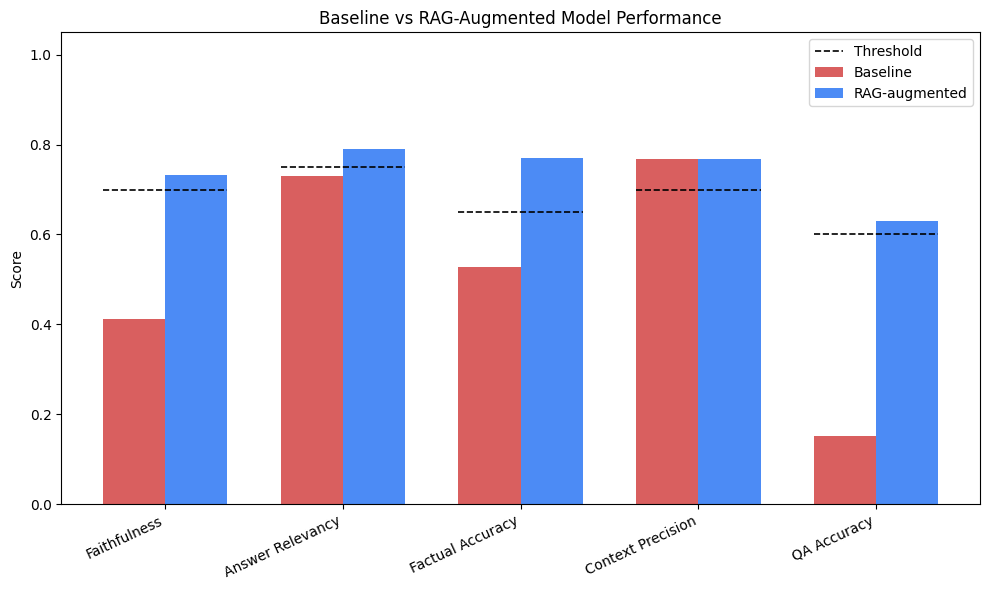

In [51]:
# Plot a bar graph comparing RAG to the baseline model
fig, ax = plt.subplots(figsize = (10, 6))

x = range(len(summary_df))
width = 0.35

# Plot the baseline and RAG bars
bars_baseline = ax.bar([i - width/2 for i in x], summary_df["Baseline"], width, label = "Baseline", color = "#d95f5f")
bars_rag = ax.bar([i + width/2 for i in x], summary_df["RAG"], width, label = "RAG-augmented", color = "#4c8bf5")

# Set the threshold marker
for i, threshold in enumerate(summary_df["Threshold"]):
    ax.plot([i - width, i + width], [threshold, threshold], color = "black", linestyle = "--", linewidth = 1.2,
            label = "Threshold" if i == 0 else None)

# Set the axis and the labels
ax.set_xticks(list(x))
ax.set_xticklabels(summary_df["metric"], rotation = 25, ha = "right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_title("Baseline vs RAG-Augmented Model Performance")
ax.legend()

plt.tight_layout()
# Save figure as .png
fig.savefig("baseline_vs_rag.png", dpi = 400, bbox_inches = "tight")
# Show the chart
plt.show()

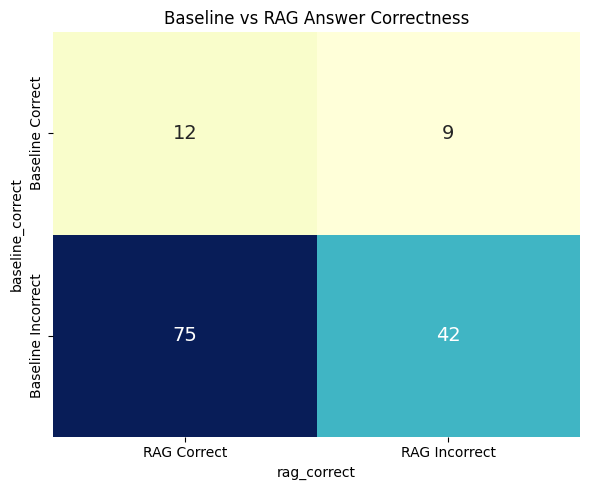

In [50]:
# Plot the answer agreement matrix between the RAG and baseline responses

# Create the agreement matrix with both baseline and RAG responses
agreement_matrix = pd.crosstab(
    acc_df["baseline_correct"].map({True: "Baseline Correct", False: "Baseline Incorrect"}),
    acc_df["rag_correct"].map({True: "RAG Correct", False: "RAG Incorrect"}),)

# Set the plot size, axis and labels
fig, ax = plt.subplots(figsize = (6, 5))
sns.heatmap(agreement_matrix, annot = True, fmt = "d", cmap = "YlGnBu", cbar = False, ax = ax, annot_kws = {"size": 14})
ax.set_title("Baseline vs RAG Answer Correctness")

plt.tight_layout()
# Save figure as .png
fig.savefig("answer_correctness_matrix.png", dpi = 400, bbox_inches = "tight")
# Show the plot
plt.show()

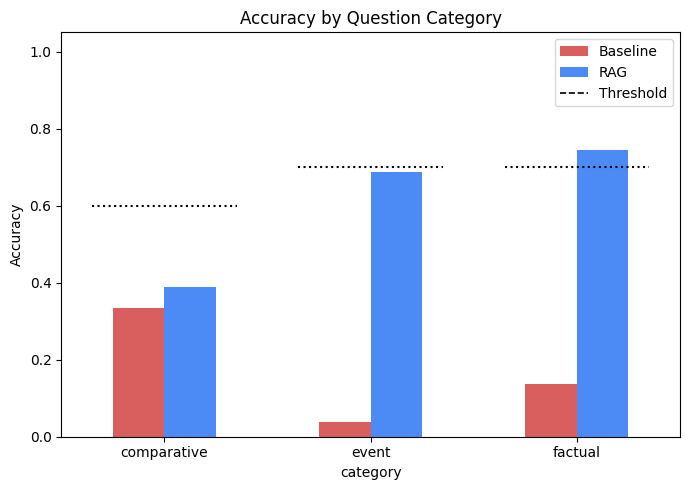

In [48]:
# Bar graph showing accuracy by question category
from matplotlib.lines import Line2D

# Bar graph showing accuracy by question category
fig, ax = plt.subplots(figsize = (7, 5))

category_acc = acc_df.groupby("category")[["baseline_correct", "rag_correct"]].mean()
category_acc.plot(kind = "bar", ax = ax, color = ["#d95f5f", "#4c8bf5"])

# Thresholds for each category
category_thresholds = {"factual": 0.70, "event": 0.70, "comparative": 0.60}

# Add a dotted threshold line over each category's bars
for i, category in enumerate(category_acc.index):
    threshold = category_thresholds[category]
    ax.hlines(y = threshold, xmin = i - 0.35, xmax = i + 0.35,
              color = "black", linestyle = ":", linewidth = 1.5)

# Set axis labels and title
ax.set_title("Accuracy by Question Category")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.tick_params(axis = "x", rotation = 0)

# Build the legend with bars first, then the threshold line
handles, _ = ax.get_legend_handles_labels()
threshold_handle = Line2D([0], [0], color = "black", linestyle = "--", linewidth = 1.2)
ax.legend(handles[:2] + [threshold_handle], ["Baseline", "RAG", "Threshold"])

plt.tight_layout()
# Save figure as .png
fig.savefig("accuracy_by_category.png", dpi = 400, bbox_inches = "tight")
# Show the graph
plt.show()

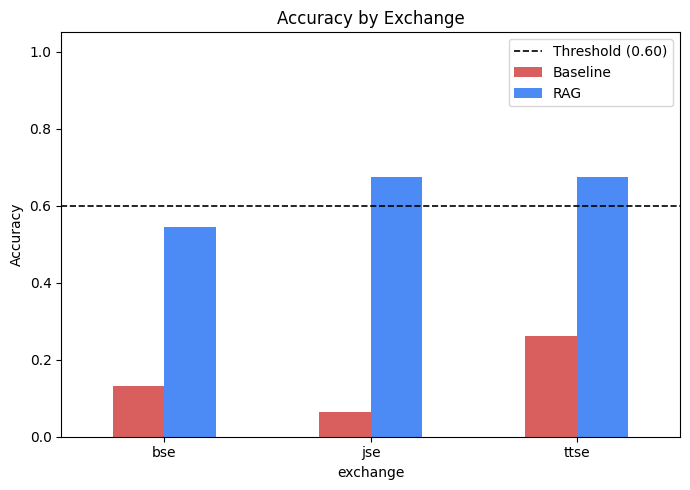

In [49]:
# Bar graph showing accuracy by exchange
fig, ax = plt.subplots(figsize = (7, 5))

# Bar graph showing accuracy by exchange
exchange_acc = acc_df.groupby("exchange")[["baseline_correct", "rag_correct"]].mean()
exchange_acc.plot(kind = "bar", ax = ax, color = ["#d95f5f", "#4c8bf5"])

# Add a dotted threshold line at 0.60
ax.axhline(y = 0.60, color = "black", linestyle = "--", linewidth = 1.2)

# Set the axis labels and title
ax.set_title("Accuracy by Exchange")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.legend(["Threshold (0.60)", "Baseline", "RAG"])
ax.tick_params(axis = "x", rotation = 0)

plt.tight_layout()
# Save figure as .png
fig.savefig("accuracy_by_exchange.png", dpi = 400, bbox_inches = "tight")
# Show the graph
plt.show()

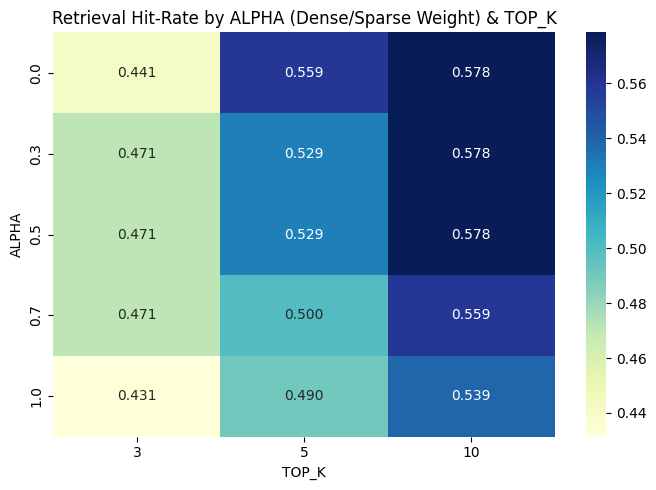

In [52]:
# Create a heat map showing the hit-rate by parameter combinations

# Pivot the retreival results DataFrame
pivot = sweep_df.pivot(index = "alpha", columns = "top_k", values = "hit_rate")

# Create the heat map with the retrieval hit-rate results
fig, ax = plt.subplots(figsize = (7, 5))
sns.heatmap(pivot, annot = True, fmt = ".3f", cmap = "YlGnBu", ax = ax)
ax.set_title("Retrieval Hit-Rate by ALPHA (Dense/Sparse Weight) & TOP_K")
ax.set_xlabel("TOP_K")
ax.set_ylabel("ALPHA")

plt.tight_layout()
# Save figure as .png
fig.savefig("retrieval-hit_matrix.png", dpi = 400, bbox_inches = "tight")
# Show the heat map
plt.show()